In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df1=pd.read_csv('Mon_IDS.csv')
df1.head()

,Protocol,Flow Duration,Total Fwd Packets,Fwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,...,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Idle Std,Attack
0,6,4,2,12,6,6,0,0,3.000000e+06,5.000000e+05,...,0,0,329,-1,20,0.0,0.0,0,0.0,0
1,6,1,2,12,6,6,0,0,1.200000e+07,2.000000e+06,...,0,0,329,-1,20,0.0,0.0,0,0.0,0
2,6,3,2,12,6,6,0,0,4.000000e+06,6.666667e+05,...,0,0,245,-1,20,0.0,0.0,0,0.0,0
3,6,1,2,12,6,6,0,0,1.200000e+07,2.000000e+06,...,0,0,245,-1,20,0.0,0.0,0,0.0,0
4,6,609,7,484,233,0,207,0,1.474548e+06,1.806240e+04,...,0,0,8192,2053,20,0.0,0.0,0,0.0,0


In [4]:
print(df1.shape)
print(df1.columns)

(458831, 78)
Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Cou

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458831 entries, 0 to 458830
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  458831 non-null  int8    
 1   Flow Duration             458831 non-null  int32   
 2   Total Fwd Packets         458831 non-null  int32   
 3   Total Backward Packets    458831 non-null  int32   
 4   Fwd Packets Length Total  458831 non-null  int32   
 5   Bwd Packets Length Total  458831 non-null  int32   
 6   Fwd Packet Length Max     458831 non-null  int16   
 7   Fwd Packet Length Min     458831 non-null  int16   
 8   Fwd Packet Length Mean    458831 non-null  float32 
 9   Fwd Packet Length Std     458831 non-null  float32 
 10  Bwd Packet Length Max     458831 non-null  int16   
 11  Bwd Packet Length Min     458831 non-null  int16   
 12  Bwd Packet Length Mean    458831 non-null  float32 
 13  Bwd Packet Length Std     458

In [6]:
df1['Label'].value_counts()
#df1['Attack'].value_counts()

,count
Label,
Benign,458831


In [7]:
df1 = df1.rename(columns={'Label': 'Attack'})
df1['Attack'] = df1['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)
df1.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [8]:
df1["Attack"].value_counts()

,count
Attack,
0,458831


In [9]:
df1.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

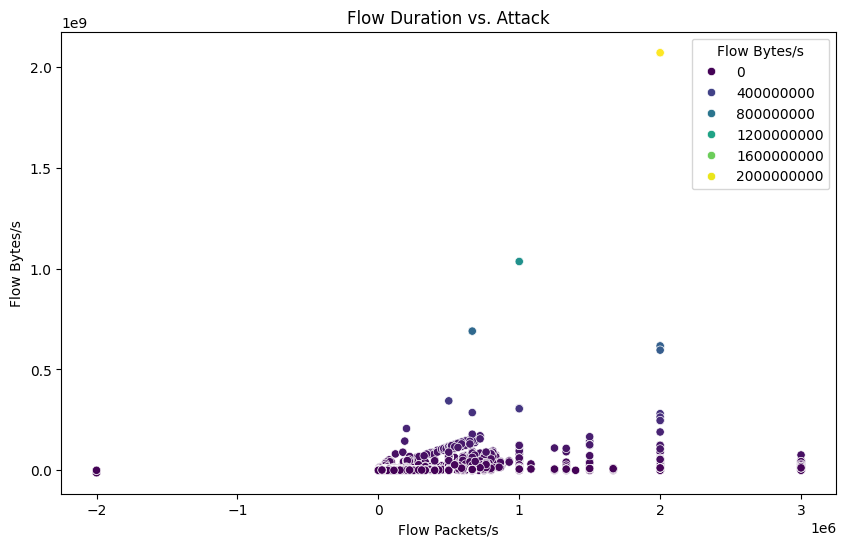

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Flow Packets/s", y="Flow Bytes/s", hue="Flow Bytes/s", data=df1, palette="viridis")
plt.title("Flow Duration vs. Attack")
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import joblib

In [12]:
X_train = df1.drop(columns=["Attack"], errors="ignore")


In [13]:
X_train.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,5,20,0.0,0.0,0,0,0.0,0.0,0,0


In [14]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [15]:
# Train Isolation Forest
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.2,
    random_state=42
)

In [16]:
iso_model.fit(X_train_scaled)

# Save models
joblib.dump(iso_model, "iso_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [17]:
df1.shape





(458831, 78)

In [18]:
df2=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/WebAttacks-Thursday-no-metadata.parquet')

df2.tail()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
155815,6,49,3,0,76,0,45,0,25.333334,23.028967,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
155816,6,1286687,41,42,2664,6954,456,0,64.975609,109.864571,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
155817,6,181,3,1,18,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
155818,6,217,2,1,31,6,31,0,15.500000,21.920311,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
155819,6,1387547,41,46,2728,6634,456,0,66.536583,110.129944,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [19]:
df2["Label"].value_counts()

,count
Label,
Benign,153677
Web Attack � Brute Force,1470
Web Attack � XSS,652
Web Attack � Sql Injection,21


In [20]:
print(df2.shape)

(155820, 78)


In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155820 entries, 0 to 155819
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  155820 non-null  int8    
 1   Flow Duration             155820 non-null  int32   
 2   Total Fwd Packets         155820 non-null  int32   
 3   Total Backward Packets    155820 non-null  int32   
 4   Fwd Packets Length Total  155820 non-null  int32   
 5   Bwd Packets Length Total  155820 non-null  int32   
 6   Fwd Packet Length Max     155820 non-null  int16   
 7   Fwd Packet Length Min     155820 non-null  int16   
 8   Fwd Packet Length Mean    155820 non-null  float32 
 9   Fwd Packet Length Std     155820 non-null  float32 
 10  Bwd Packet Length Max     155820 non-null  int16   
 11  Bwd Packet Length Min     155820 non-null  int16   
 12  Bwd Packet Length Mean    155820 non-null  float32 
 13  Bwd Packet Length Std     155

In [22]:
df3=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/DoS-Wednesday-no-metadata.parquet')
df41=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/Infiltration-Thursday-no-metadata.parquet')
df42=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/WebAttacks-Thursday-no-metadata.parquet')

In [23]:
df3.shape


(584991, 78)

In [24]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584991 entries, 0 to 584990
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  584991 non-null  int8    
 1   Flow Duration             584991 non-null  int32   
 2   Total Fwd Packets         584991 non-null  int32   
 3   Total Backward Packets    584991 non-null  int32   
 4   Fwd Packets Length Total  584991 non-null  int32   
 5   Bwd Packets Length Total  584991 non-null  int32   
 6   Fwd Packet Length Max     584991 non-null  int16   
 7   Fwd Packet Length Min     584991 non-null  int16   
 8   Fwd Packet Length Mean    584991 non-null  float32 
 9   Fwd Packet Length Std     584991 non-null  float32 
 10  Bwd Packet Length Max     584991 non-null  int16   
 11  Bwd Packet Length Min     584991 non-null  int16   
 12  Bwd Packet Length Mean    584991 non-null  float32 
 13  Bwd Packet Length Std     584

In [25]:
df3['Label'].value_counts()

,count
Label,
Benign,391235
DoS Hulk,172846
DoS GoldenEye,10286
DoS slowloris,5385
DoS Slowhttptest,5228
Heartbleed,11


In [26]:

df41.shape

(207630, 78)

In [27]:
df41.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207630 entries, 0 to 207629
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  207630 non-null  int8    
 1   Flow Duration             207630 non-null  int32   
 2   Total Fwd Packets         207630 non-null  int16   
 3   Total Backward Packets    207630 non-null  int32   
 4   Fwd Packets Length Total  207630 non-null  int32   
 5   Bwd Packets Length Total  207630 non-null  int32   
 6   Fwd Packet Length Max     207630 non-null  int16   
 7   Fwd Packet Length Min     207630 non-null  int16   
 8   Fwd Packet Length Mean    207630 non-null  float32 
 9   Fwd Packet Length Std     207630 non-null  float32 
 10  Bwd Packet Length Max     207630 non-null  int16   
 11  Bwd Packet Length Min     207630 non-null  int16   
 12  Bwd Packet Length Mean    207630 non-null  float32 
 13  Bwd Packet Length Std     207

In [28]:
df41['Label'].value_counts()

,count
Label,
Benign,207594
Infiltration,36


In [29]:
df42.shape

(155820, 78)

In [30]:
df42.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155820 entries, 0 to 155819
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  155820 non-null  int8    
 1   Flow Duration             155820 non-null  int32   
 2   Total Fwd Packets         155820 non-null  int32   
 3   Total Backward Packets    155820 non-null  int32   
 4   Fwd Packets Length Total  155820 non-null  int32   
 5   Bwd Packets Length Total  155820 non-null  int32   
 6   Fwd Packet Length Max     155820 non-null  int16   
 7   Fwd Packet Length Min     155820 non-null  int16   
 8   Fwd Packet Length Mean    155820 non-null  float32 
 9   Fwd Packet Length Std     155820 non-null  float32 
 10  Bwd Packet Length Max     155820 non-null  int16   
 11  Bwd Packet Length Min     155820 non-null  int16   
 12  Bwd Packet Length Mean    155820 non-null  float32 
 13  Bwd Packet Length Std     155

In [31]:
df42['Label'].value_counts()

,count
Label,
Benign,153677
Web Attack � Brute Force,1470
Web Attack � XSS,652
Web Attack � Sql Injection,21


In [32]:
df51=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/Botnet-Friday-no-metadata.parquet')
df52=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/DDoS-Friday-no-metadata.parquet')
df53=pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/Portscan-Friday-no-metadata.parquet')


In [33]:
df51.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,112740690,32,16,6448,1152,403,0,201.5,204.724197,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,Benign
1,6,112740560,32,16,6448,5056,403,0,201.5,204.724197,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,Benign
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,Benign
3,17,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Benign
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Benign


In [34]:
df52.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [35]:
df53.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,1266342,41,44,2664,6954,456,0,64.975609,109.864571,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1319353,41,44,2664,6954,456,0,64.975609,109.864571,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1303488,41,42,2728,6634,456,0,66.536583,110.129944,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [36]:
print(df51.shape)
print(df52.shape)
print(df53.shape)

(176038, 78)
(221264, 78)
(119522, 78)


In [37]:
df51.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176038 entries, 0 to 176037
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  176038 non-null  int8    
 1   Flow Duration             176038 non-null  int32   
 2   Total Fwd Packets         176038 non-null  int32   
 3   Total Backward Packets    176038 non-null  int32   
 4   Fwd Packets Length Total  176038 non-null  int32   
 5   Bwd Packets Length Total  176038 non-null  int32   
 6   Fwd Packet Length Max     176038 non-null  int16   
 7   Fwd Packet Length Min     176038 non-null  int16   
 8   Fwd Packet Length Mean    176038 non-null  float32 
 9   Fwd Packet Length Std     176038 non-null  float32 
 10  Bwd Packet Length Max     176038 non-null  int16   
 11  Bwd Packet Length Min     176038 non-null  int16   
 12  Bwd Packet Length Mean    176038 non-null  float32 
 13  Bwd Packet Length Std     176

In [38]:
df52.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221264 entries, 0 to 221263
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  221264 non-null  int8    
 1   Flow Duration             221264 non-null  int32   
 2   Total Fwd Packets         221264 non-null  int16   
 3   Total Backward Packets    221264 non-null  int16   
 4   Fwd Packets Length Total  221264 non-null  int32   
 5   Bwd Packets Length Total  221264 non-null  int32   
 6   Fwd Packet Length Max     221264 non-null  int16   
 7   Fwd Packet Length Min     221264 non-null  int16   
 8   Fwd Packet Length Mean    221264 non-null  float32 
 9   Fwd Packet Length Std     221264 non-null  float32 
 10  Bwd Packet Length Max     221264 non-null  int16   
 11  Bwd Packet Length Min     221264 non-null  int16   
 12  Bwd Packet Length Mean    221264 non-null  float32 
 13  Bwd Packet Length Std     221

In [39]:
df53.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119522 entries, 0 to 119521
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   Protocol                  119522 non-null  int8    
 1   Flow Duration             119522 non-null  int32   
 2   Total Fwd Packets         119522 non-null  int16   
 3   Total Backward Packets    119522 non-null  int16   
 4   Fwd Packets Length Total  119522 non-null  int32   
 5   Bwd Packets Length Total  119522 non-null  int32   
 6   Fwd Packet Length Max     119522 non-null  int16   
 7   Fwd Packet Length Min     119522 non-null  int16   
 8   Fwd Packet Length Mean    119522 non-null  float32 
 9   Fwd Packet Length Std     119522 non-null  float32 
 10  Bwd Packet Length Max     119522 non-null  int16   
 11  Bwd Packet Length Min     119522 non-null  int16   
 12  Bwd Packet Length Mean    119522 non-null  float32 
 13  Bwd Packet Length Std     119

In [40]:
df51['Label'].value_counts()

,count
Label,
Benign,174601
Bot,1437


In [41]:
df52['Label'].value_counts()

,count
Label,
DDoS,128014
Benign,93250


In [42]:
df53['Label'].value_counts()

,count
Label,
Benign,117566
PortScan,1956


In [43]:
df_all=pd.concat([df2,df3,df41,df42,df51,df52,df53],axis=0)
df_all.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,113095465,48,24,9668,10012,403,0,201.416672,203.548294,...,32,203985.500,5.758372e+05,1629110,379,13800000.0,4277541.0,16500000,6737603,Benign
1,6,113473706,68,40,11364,12718,403,0,167.117645,171.919418,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4229413.0,16500000,6945512,Benign
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.500,1.170000e+07,20400000,6,24400000.0,24300000.0,60100000,5702188,Benign
3,6,60261928,9,7,2330,4221,1093,0,258.888885,409.702148,...,20,0.000,0.000000e+00,0,0,0.0,0.0,0,0,Benign
4,17,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.0,0,0,Benign


In [44]:
df_all.shape

(1621085, 78)

In [45]:
df_all['Label'].value_counts()

,count
Label,
Benign,1291600
DoS Hulk,172846
DDoS,128014
DoS GoldenEye,10286
DoS slowloris,5385
DoS Slowhttptest,5228
Web Attack � Brute Force,2940
PortScan,1956
Bot,1437


In [46]:
df_all = df_all.rename(columns={'Label': 'Attack'})

In [47]:
df_all['Attack'] = df_all['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)

In [48]:
df_all.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack
0,6,113095465,48,24,9668,10012,403,0,201.416672,203.548294,...,32,203985.500,5.758372e+05,1629110,379,13800000.0,4277541.0,16500000,6737603,0
1,6,113473706,68,40,11364,12718,403,0,167.117645,171.919418,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4229413.0,16500000,6945512,0
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.500,1.170000e+07,20400000,6,24400000.0,24300000.0,60100000,5702188,0
3,6,60261928,9,7,2330,4221,1093,0,258.888885,409.702148,...,20,0.000,0.000000e+00,0,0,0.0,0.0,0,0,0
4,17,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.0,0,0,0


In [49]:
df_all['Attack'].value_counts()

,count
Attack,
0,1291600
1,329485


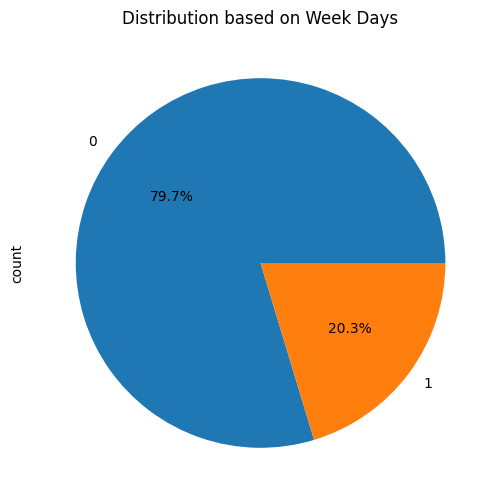

In [50]:
# Pie chart (Week Day)
plt.figure(figsize=(6, 6))
df_all['Attack'].value_counts().plot.pie(
    autopct="%1.1f%%")
plt.title("Distribution based on Week Days")
plt.show()
#

<Axes: >

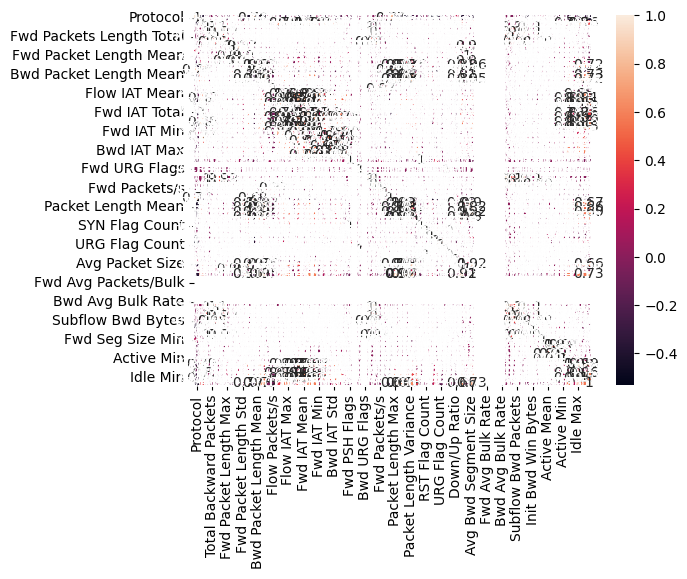

In [51]:
sns.heatmap(df_all.corr(), annot=True)

In [52]:
corr = df_all.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr2 = [column for column in upper.columns if any(upper[column] > 0.9)]

high_corr2

['Total Backward Packets',
 'Bwd Packets Length Total',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow IAT Max',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Bwd IAT Min',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'SYN Flag Count',
 'CWE Flag Count',
 'ECE Flag Count',
 'Avg Packet Size',
 'Avg Fwd Segment Size',
 'Avg Bwd Segment Size',
 'Subflow Fwd Packets',
 'Subflow Fwd Bytes',
 'Subflow Bwd Packets',
 'Subflow Bwd Bytes',
 'Fwd Act Data Packets',
 'Active Min',
 'Idle Mean',
 'Idle Max',
 'Idle Min']

In [53]:
len(high_corr2)

34

<Axes: >

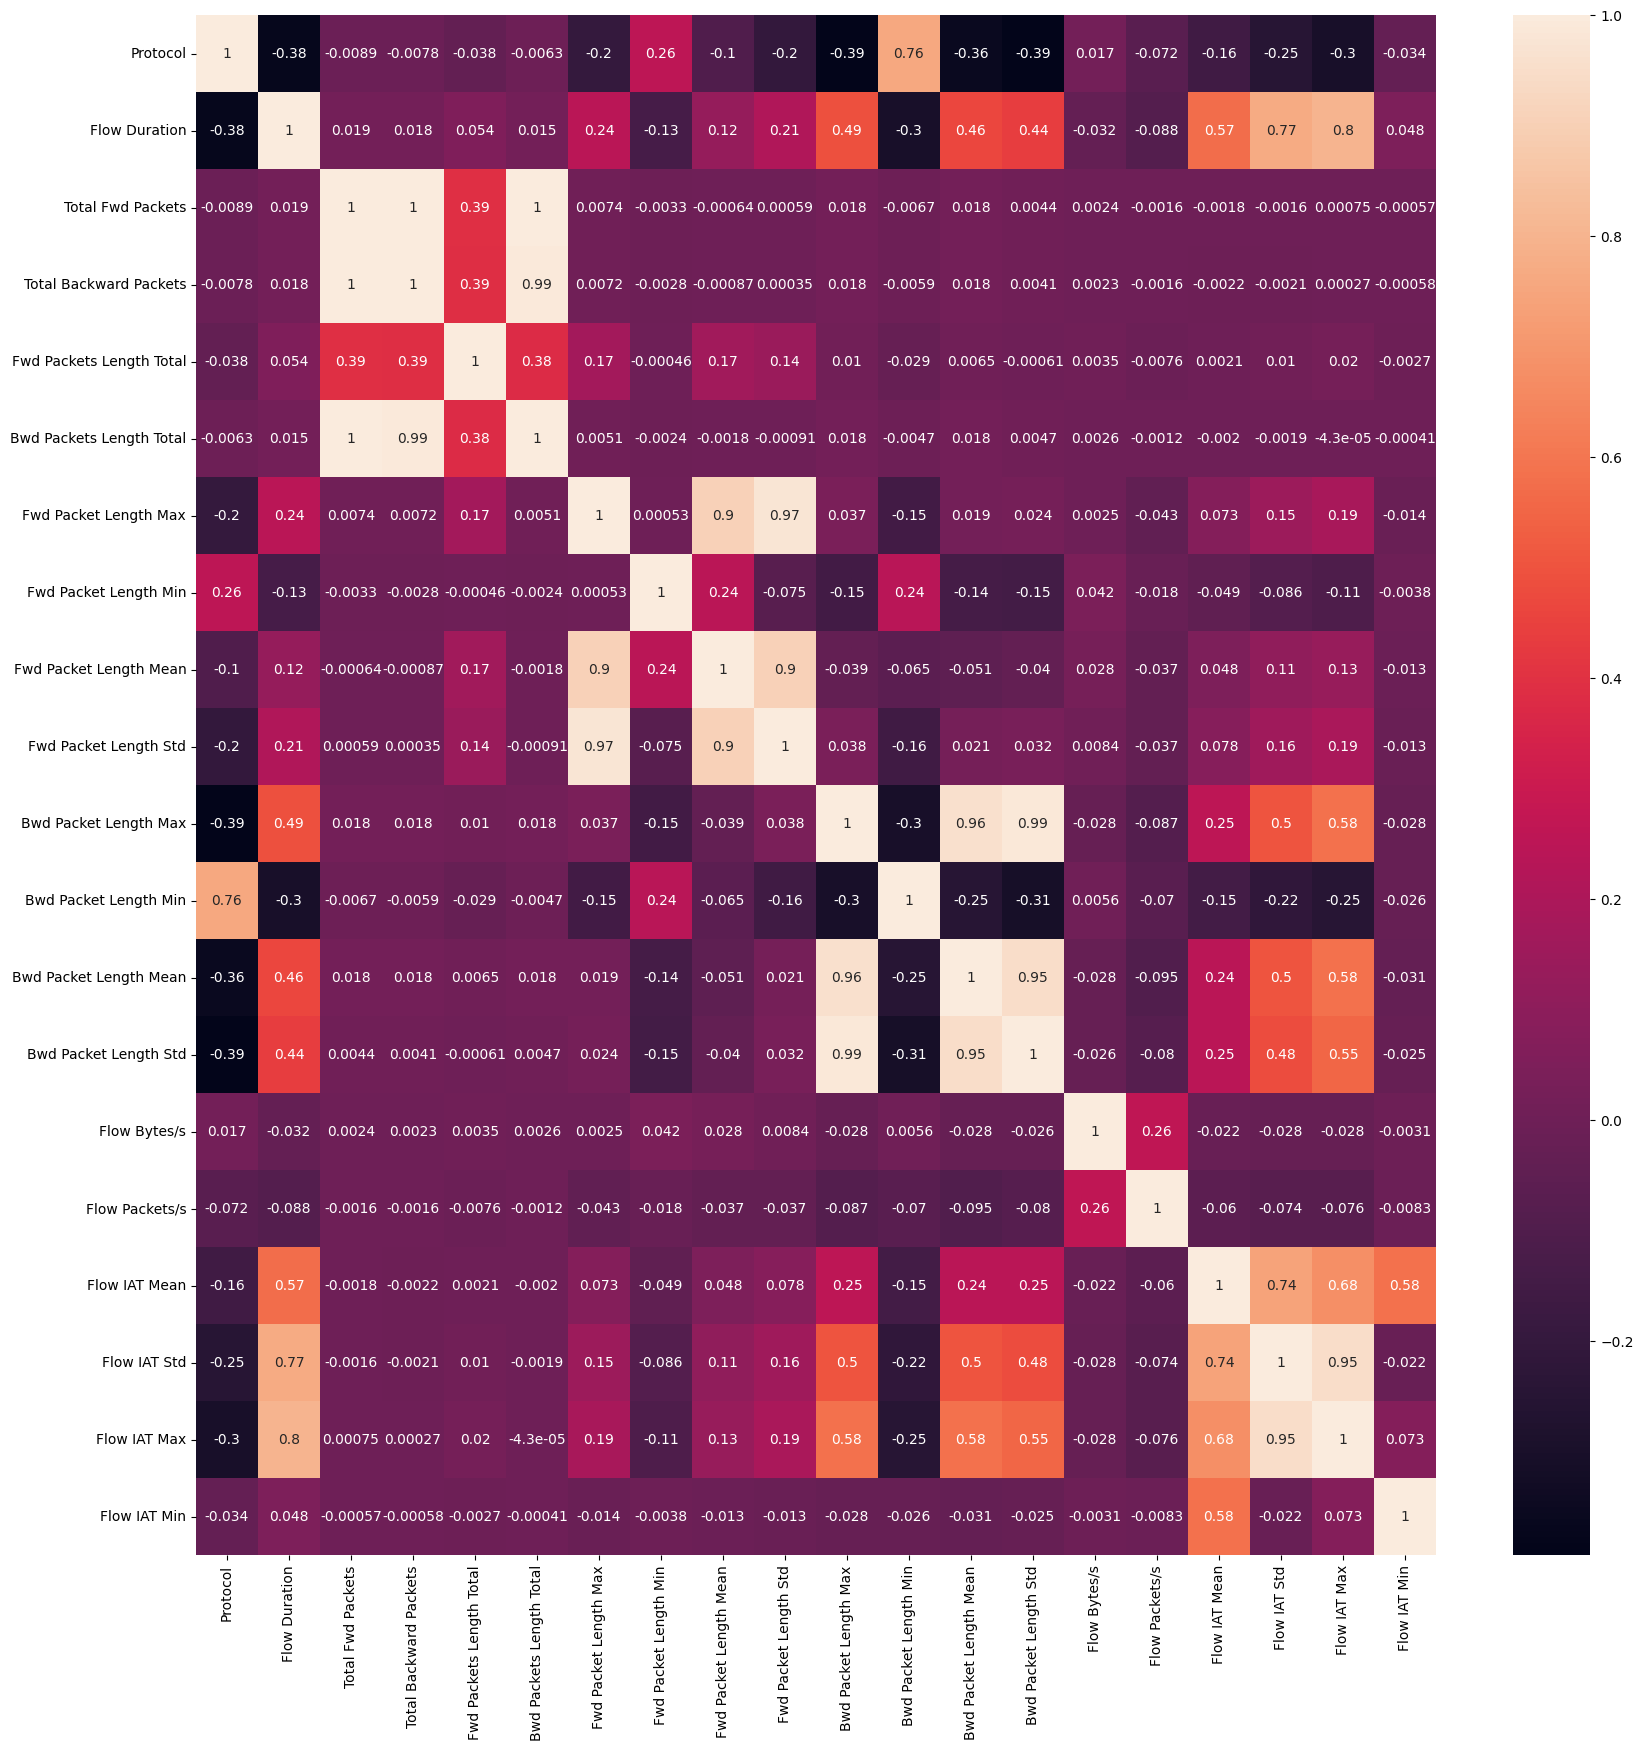

In [54]:
subset_df = df_all.iloc[:,0:20]
fig, ax = plt.subplots(figsize=(20, 20), dpi=100)
sns.heatmap(subset_df.corr(), annot=True)

In [55]:
df_reduced=df_all.drop(columns=high_corr2)

In [56]:
df_reduced.head()

,Protocol,Flow Duration,Total Fwd Packets,Fwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,...,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Idle Std,Attack
0,6,113095465,48,9668,403,0,923,316,1.740123e+02,0.636630,...,0,0,571,2079,32,203985.500,5.758372e+05,1629110,4277541.0,0
1,6,113473706,68,11364,403,0,1139,126,2.122254e+02,0.951762,...,0,0,390,2081,32,178326.875,5.034269e+05,1424245,4229413.0,0
2,0,119945515,150,0,0,0,0,0,0.000000e+00,1.250568,...,0,0,-1,-1,0,6909777.500,1.170000e+07,20400000,24300000.0,0
3,6,60261928,9,2330,1093,0,1460,0,1.087088e+02,0.265508,...,0,0,8192,513,20,0.000,0.000000e+00,0,0.0,0
4,17,269,2,102,51,51,161,161,1.576208e+06,14869.888480,...,0,0,-1,-1,32,0.000,0.000000e+00,0,0.0,0


In [57]:
df_reduced.shape

(1621085, 44)

In [58]:
df_reduced.to_csv('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/TueToFri_IDS.csv', index=False)

In [59]:
df1=df1.drop(columns=high_corr2,errors="ignore")

In [60]:
df1.shape

(458831, 44)

In [61]:
df1.to_csv('/content/drive/MyDrive/Colab Notebooks/AI-Powered Cybersecurity Intrusion Detection System/Mon_IDS.csv', index=False)